In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
import random

c:\Users\Soufiane1\Desktop\projects\ai\agentic\langGraph_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
nouns = ["Cabbages", "Unicorns", "Toasters", "Penguins", "Bananas", "Zombies", "Rainbows", "Eels", "Pickles", "Muffins"]
adjectives = ["outrageous", "smelly", "pedantic", "existential", "moody", "sparkly", "untrustworthy", "sarcastic", "squishy", "haunted"]

In [5]:
class State(BaseModel):
      messages: Annotated[list, add_messages]

In [6]:
graph_builder = StateGraph(State)

In [7]:
def my_first_node(old_state: State)-> State:
      reply = f"{random.choice(nouns)} are {random.choice(adjectives)}"
      messages = [{"role": "assistant", "content": reply}]

      new_state = State(messages=messages)

      return new_state

graph_builder.add_node("first_node", my_first_node)

In [8]:
graph_builder.add_edge(START, "first_node")
graph_builder.add_edge("first_node", END)

In [9]:
graph = graph_builder.compile()

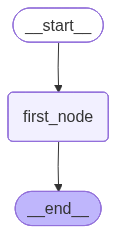

In [11]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
##gradio chat 
def chat(input:str, history):
      messages = [{"role":"user","content":input}]
      state = State(messages=messages)
      result=graph.invoke(state)
      print(result)
      return result["messages"][-1].content
gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hey', additional_kwargs={}, response_metadata={}, id='1a8bf58c-885b-4833-b341-e3f9816b78c9'), AIMessage(content='Pickles are outrageous', additional_kwargs={}, response_metadata={}, id='21657d5f-bd8d-40d2-beb3-1c8966ac7dc8', tool_calls=[], invalid_tool_calls=[])]}
